
# Reusable Template: Simple Linear Regression Project (OLS)

Use this notebook as a starting point for a new simple-linear-regression
project. Replace the `CONFIG` values in Step 0 and the data-loading cell in
Step 1, then run top to bottom — every downstream cell is written generically
against `df`, `TARGET`, and `PREDICTOR` so it should work unmodified for most
two-variable OLS problems.

**Workflow stages:**
0. Configuration
1. Load & inspect data
2. Fit baseline OLS model
3. Assumption checks (linearity, normality, homoscedasticity)
4. Full diagnostic plot suite
5. Serial correlation check (skip if your data isn't sequential/time-ordered)
6. Train/test validation vs. naive baseline
7. Reporting summary (fill in your conclusions)


## Step 0 — Configuration

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.stattools import durbin_watson
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

sns.set_style("whitegrid")

# ============ EDIT THESE FOR YOUR PROJECT ============
TARGET = "realdpi"          # name of the dependent / response variable column
PREDICTOR = "realinv"       # name of the independent / explanatory variable column
IS_TIME_ORDERED = True      # True if rows are ordered by time (affects Step 5)
RANDOM_SEED = 42
TRAIN_FRACTION = 0.75
# =======================================================


## Step 1 — Load & Inspect Data

Replace this cell with your own data source (`pd.read_csv(...)`, a database query, etc.). The example below uses the `statsmodels` macrodata dataset as a placeholder.

In [2]:
# --- EXAMPLE data load; replace with your own source ---
raw = sm.datasets.macrodata.load().data
raw = sm.add_constant(raw, prepend=False)
df = raw[[TARGET, PREDICTOR, 'const']].copy()
# ---------------------------------------------------------

print(df.shape)
df.head()


(203, 3)


,realdpi,realinv,const
0,1886.9,286.898,1.0
1,1919.7,310.859,1.0
2,1916.4,289.226,1.0
3,1931.3,299.356,1.0
4,1955.5,331.722,1.0


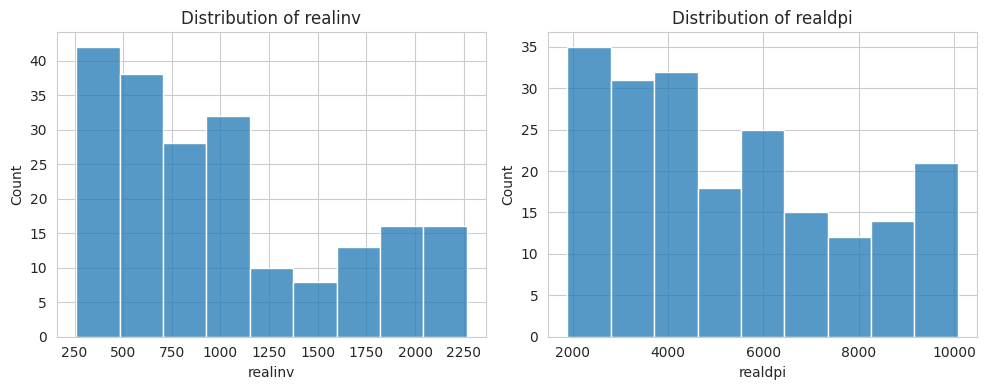

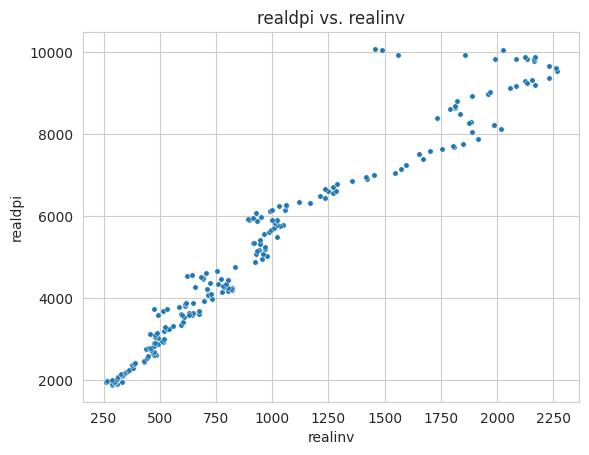

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(df[PREDICTOR], ax=ax[0]); ax[0].set_title(f"Distribution of {PREDICTOR}")
sns.histplot(df[TARGET], ax=ax[1]); ax[1].set_title(f"Distribution of {TARGET}")
fig.tight_layout()
plt.show()

fig2 = sns.scatterplot(x=df[PREDICTOR], y=df[TARGET], s=15)
fig2.set(xlabel=PREDICTOR, ylabel=TARGET, title=f"{TARGET} vs. {PREDICTOR}")
plt.show()


**Check before proceeding:** does the scatter plot look plausibly linear? If it's clearly curved, a simple linear model is the wrong tool — consider a transformation (log, polynomial term) or a different model class before continuing.

## Step 2 — Fit Baseline OLS Model

In [4]:
X_cols = ['const', PREDICTOR]
ols_model = sm.OLS(df[TARGET], df[X_cols])
fitted = ols_model.fit()
print(fitted.summary())


                            OLS Regression Results                            
Dep. Variable:                realdpi   R-squared:                       0.944
Model:                            OLS   Adj. R-squared:                  0.944
Method:                 Least Squares   F-statistic:                     3384.
Date:                Wed, 26 Aug 2026   Prob (F-statistic):          1.01e-127
Time:                        20:44:38   Log-Likelihood:                -1577.1
No. Observations:                 203   AIC:                             3158.
Df Residuals:                     201   BIC:                             3165.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1234.5164     80.866     15.266      0.0

**Reading checklist:**
- p-value for `PREDICTOR` < 0.05? → statistically significant relationship
- 95% CI for `PREDICTOR` excludes 0? → consistent with the p-value
- R-squared → proportion of variance in `TARGET` explained by `PREDICTOR`
- Durbin-Watson far from 2? → possible serial correlation (see Step 5)
- Cond. No. large (>30, especially >1000)? → possible scaling/multicollinearity issue

## Step 3 — Assumption Checks

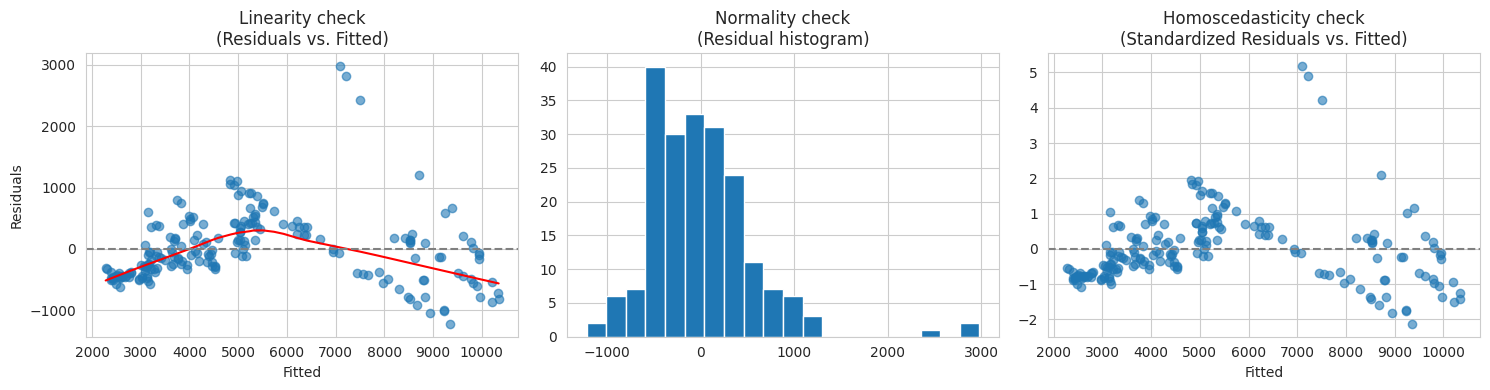

In [5]:
residuals = fitted.resid
fitted_values = fitted.fittedvalues

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

# Linearity
lw = lowess(residuals, fitted_values)
ax[0].scatter(fitted_values, residuals, alpha=0.6)
ax[0].plot(lw[:, 0], lw[:, 1], color='red')
ax[0].axhline(0, color='grey', linestyle='--')
ax[0].set_title('Linearity check\n(Residuals vs. Fitted)')
ax[0].set_xlabel('Fitted'); ax[0].set_ylabel('Residuals')

# Normality
ax[1].hist(residuals, bins=20)
ax[1].set_title('Normality check\n(Residual histogram)')

# Homoscedasticity
standardized = fitted.resid_pearson
ax[2].scatter(fitted_values, standardized, alpha=0.6)
ax[2].axhline(0, color='grey', linestyle='--')
ax[2].set_title('Homoscedasticity check\n(Standardized Residuals vs. Fitted)')
ax[2].set_xlabel('Fitted')

fig.tight_layout()
plt.show()


**Independence** cannot be checked from a plot in general — it depends on how the data were sampled/collected. If `IS_TIME_ORDERED = True`, proceed to Step 5 for a formal check.

## Step 4 — Full Diagnostic Plot Suite (Fitted / Q-Q / Scale-Location / Leverage)

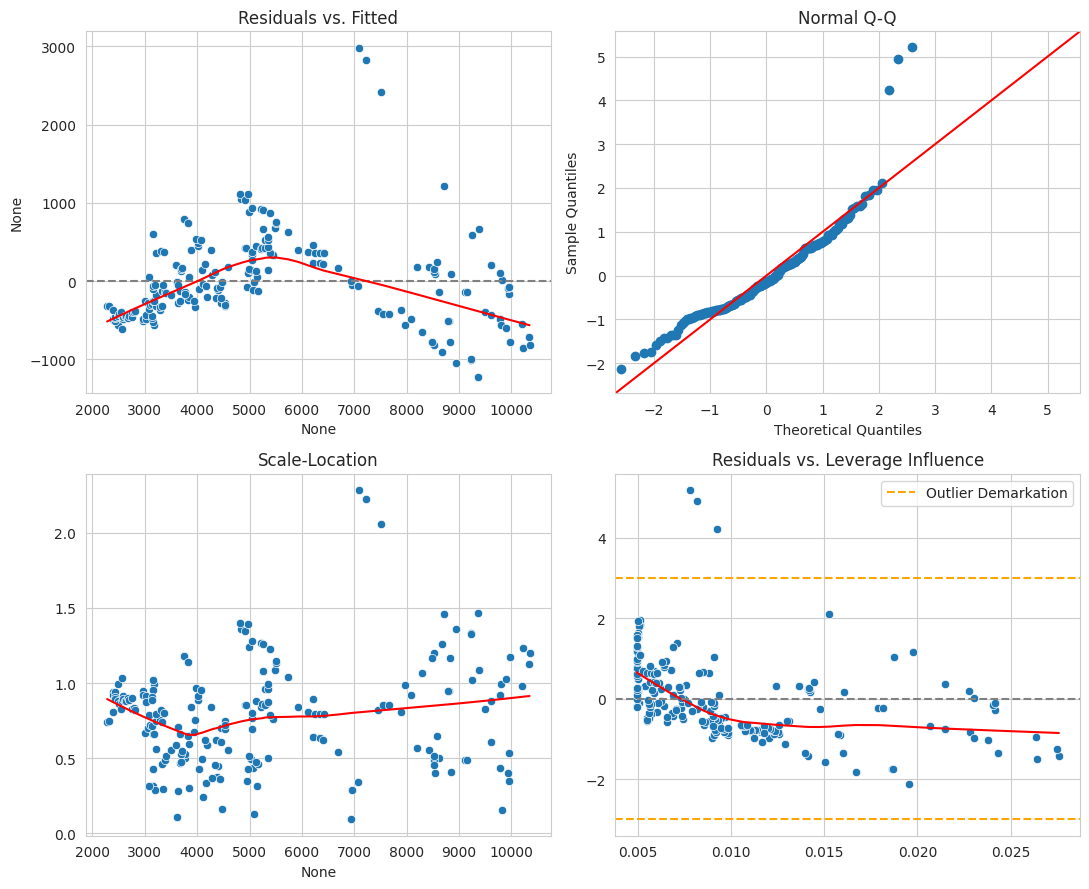

Number of points with |standardized residual| > 3: 3
Number of points with Cook's distance > 0.5: 0


In [6]:
model_residuals = fitted.resid
fitted_value = fitted.fittedvalues
standardized_residuals = fitted.resid_pearson
sqrt_standardized_residuals = np.sqrt(np.abs(fitted.get_influence().resid_studentized_internal))
influence = fitted.get_influence()
leverage = influence.hat_matrix_diag
cooks_distance = fitted.get_influence().cooks_distance[0]

fig, ax = plt.subplots(2, 2, figsize=(11, 9))

lw1 = lowess(model_residuals, fitted_value)
sns.scatterplot(x=fitted_value, y=model_residuals, ax=ax[0, 0])
ax[0, 0].axhline(0, color='grey', linestyle='--')
ax[0, 0].plot(lw1[:, 0], lw1[:, 1], color='red')
ax[0, 0].set_title('Residuals vs. Fitted')

sm.qqplot(model_residuals, fit=True, line='45', ax=ax[0, 1])
ax[0, 1].set_title('Normal Q-Q')

lw2 = lowess(sqrt_standardized_residuals, fitted_value)
sns.scatterplot(x=fitted_value, y=sqrt_standardized_residuals, ax=ax[1, 0])
ax[1, 0].plot(lw2[:, 0], lw2[:, 1], color='red')
ax[1, 0].set_title('Scale-Location')

lw3 = lowess(standardized_residuals, leverage)
sns.scatterplot(x=leverage, y=standardized_residuals, ax=ax[1, 1])
ax[1, 1].plot(lw3[:, 0], lw3[:, 1], color='red')
ax[1, 1].axhline(0, color='grey', linestyle='--')
ax[1, 1].axhline(3, color='orange', linestyle='--', label='Outlier Demarkation')
ax[1, 1].axhline(-3, color='orange', linestyle='--')
ax[1, 1].legend(loc='upper right')
ax[1, 1].set_title('Residuals vs. Leverage Influence')

flagged = [i for i in range(len(cooks_distance)) if cooks_distance[i] > 0.5]
for i in flagged:
    ax[1, 1].annotate(f"{i}: Cook's D > 0.5", xy=(leverage[i], standardized_residuals[i]))
if flagged:
    ax[1, 1].axvline(min(leverage[i] for i in flagged), color='red', linestyle='--')

fig.tight_layout()
plt.show()

print(f"Number of points with |standardized residual| > 3: "
      f"{int((np.abs(standardized_residuals) > 3).sum())}")
print(f"Number of points with Cook's distance > 0.5: {len(flagged)}")


## Step 5 — Serial Correlation Check (time-ordered data only)

Durbin-Watson statistic: 0.095
Rule of thumb: ~2 = no autocorrelation; <1.5 = positive autocorrelation; >2.5 = negative.


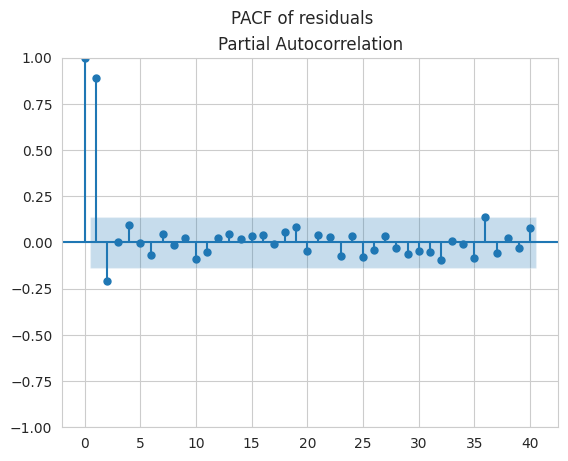

In [7]:
if IS_TIME_ORDERED:
    dw = durbin_watson(fitted.resid)
    print(f"Durbin-Watson statistic: {dw:.3f}")
    print("Rule of thumb: ~2 = no autocorrelation; <1.5 = positive autocorrelation; >2.5 = negative.")

    n_lags = min(40, len(fitted.resid) // 2 - 1)
    fig = plot_pacf(fitted.resid, alpha=0.05, lags=n_lags)
    fig.suptitle("PACF of residuals")
    plt.show()
else:
    print("IS_TIME_ORDERED is False -- skipping serial correlation diagnostics.")
    print("(Independence should instead be justified by your sampling design.)")


**If Durbin-Watson is far from 2 and IS_TIME_ORDERED is True**, consider re-running
Steps 2-4 on first-order-differenced versions of `TARGET` and `PREDICTOR`:

```python
diffed_target = np.diff(df[TARGET], n=1)
diffed_predictor = np.diff(df[PREDICTOR], n=1)
const_for_diff = df['const'].iloc[:-1].reset_index(drop=True)
diffed_model = sm.OLS(diffed_target,
                       pd.concat([const_for_diff, pd.Series(diffed_predictor)], axis=1)).fit()
```

Remember: differencing changes the *interpretation* of the model from a
levels relationship to a rate-of-change relationship, and a persistent
autocorrelation problem is often better solved with a dedicated time-series
model than by differencing alone.

## Step 6 — Train/Test Validation vs. Naive Baseline

In [8]:
train, test = train_test_split(df, train_size=TRAIN_FRACTION, shuffle=True, random_state=RANDOM_SEED)

model_train = sm.OLS(train[TARGET], train[X_cols]).fit()
model_test = sm.OLS(test[TARGET], test[X_cols]).fit()

print("=== Train-only fit ===")
print(model_train.params)
print(f"R-squared: {model_train.rsquared:.4f}")
print()
print("=== Test-only fit ===")
print(model_test.params)
print(f"R-squared: {model_test.rsquared:.4f}")


=== Train-only fit ===
const      1176.655996
realinv       4.073774
dtype: float64
R-squared: 0.9483

=== Test-only fit ===
const      1405.746041
realinv       3.875943
dtype: float64
R-squared: 0.9316


In [9]:
mae_train = mean_absolute_error(train[TARGET], model_train.predict(train[X_cols]))
naive_mae_train = np.mean(np.abs(train[TARGET] - train[TARGET].mean()))

mae_holdout = mean_absolute_error(test[TARGET], model_train.predict(test[X_cols]))
naive_mae_test = np.mean(np.abs(test[TARGET] - test[TARGET].mean()))

results = pd.DataFrame({
    'Split': ['Train', 'Train', 'Test (holdout)', 'Test (holdout)'],
    'Model': ['OLS', 'Naive mean', 'OLS (trained on train)', 'Naive mean'],
    'MAE': [mae_train, naive_mae_train, mae_holdout, naive_mae_test]
})
results


,Split,Model,MAE
0,Train,OLS,394.420570
1,Train,Naive mean,2068.815184
2,Test (holdout),OLS (trained on train),476.850610
3,Test (holdout),Naive mean,1999.332180


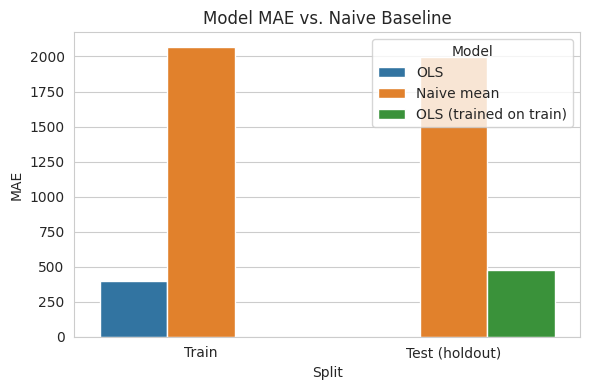

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=results, x='Split', y='MAE', hue='Model', ax=ax)
ax.set_title('Model MAE vs. Naive Baseline')
plt.tight_layout()
plt.show()


## Step 7 — Reporting Summary

Fill in your conclusions once the above has run.

In [11]:
summary_notes = """
PROJECT SUMMARY (fill this in)
--------------------------------
Target variable:        {target}
Predictor variable:     {predictor}
n observations:         {n}

Coefficient (slope):    {slope:.4f}   (p-value: {pval:.4g})
R-squared:              {r2:.4f}
Durbin-Watson:          {dw}

Assumption check summary:
  Linearity:        [PASS / CONCERNS -- describe]
  Normality:        [PASS / CONCERNS -- describe]
  Homoscedasticity: [PASS / CONCERNS -- describe]
  Independence:     [PASS / CONCERNS -- describe]

Model beats naive baseline on holdout data: {beats_naive}

Overall recommendation:
  [Your conclusion here -- e.g., "model is usable for X purpose but has
  Y limitation and would benefit from Z additional predictor / transform."]
""".format(
    target=TARGET, predictor=PREDICTOR, n=len(df),
    slope=fitted.params[PREDICTOR], pval=fitted.pvalues[PREDICTOR],
    r2=fitted.rsquared,
    dw=(f"{durbin_watson(fitted.resid):.3f}" if IS_TIME_ORDERED else "N/A"),
    beats_naive=(mae_holdout < naive_mae_test)
)
print(summary_notes)



PROJECT SUMMARY (fill this in)
--------------------------------
Target variable:        realdpi
Predictor variable:     realinv
n observations:         203

Coefficient (slope):    4.0243   (p-value: 1.009e-127)
R-squared:              0.9439
Durbin-Watson:          0.095

Assumption check summary:
  Linearity:        [PASS / CONCERNS -- describe]
  Normality:        [PASS / CONCERNS -- describe]
  Homoscedasticity: [PASS / CONCERNS -- describe]
  Independence:     [PASS / CONCERNS -- describe]

Model beats naive baseline on holdout data: True

Overall recommendation:
  [Your conclusion here -- e.g., "model is usable for X purpose but has
  Y limitation and would benefit from Z additional predictor / transform."]

